#**Travaux Pratiques : Préparation des Données**
### **Objectif**
Appliquer des techniques de préparation des données sur un jeu de données réel lié aux services de transport. Ces techniques incluent le nettoyage, la transformation, la gestion des valeurs manquantes et la création de nouvelles caractéristiques.

### **Dataset Utilisé**
Le jeu de données contient des informations sur les courses Uber, y compris les caractéristiques des trajets, comme la date et l'heure, les coordonnées de prise en charge et de dépose, ainsi que le nombre de passagers. Ce jeu de données est utilisé pour prédire le montant des courses (fare amount) et identifier d'éventuelles anomalies ou tendances dans le service.

**Imporeter les bibliothèques necessiares**

In [424]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

**Charger le dataset**

In [425]:
df = pd.read_csv('datauber.csv')
df

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194.0,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1.0
1,27835199.0,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1.0
2,44984355.0,2009-08-24 21:45:00.00000061,12.9,NaN,-74.005043,40.740770,NaN,40.772647,1.0
3,25894730.0,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,NaN,-73.965316,40.803349,3.0
4,17610152.0,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,NaN,40.744085,-73.973082,NaN,5.0
...,...,...,...,...,...,...,...,...,...
44372,35522961.0,2013-09-28 01:30:18.0000001,21.5,2013-09-28 01:30:18 UTC,-73.989875,40.719197,-73.979169,40.780914,1.0
44373,34717029.0,2014-03-28 19:28:34.0000005,5.0,2014-03-28 19:28:34 UTC,-73.994805,40.740033,-74.003328,40.732565,1.0
44374,51028248.0,2011-03-30 12:54:23.0000005,9.3,2011-03-30 12:54:23 UTC,-73.982996,40.726833,-74.005368,40.733291,2.0
44375,50834096.0,NaN,4.9,2011-11-07 22:59:56 UTC,-73.958802,40.810530,-73.945712,40.812308,1.0


In [426]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Exploration et aperçu des Données**

In [427]:
df.columns

Index(['Unnamed: 0', 'key', 'fare_amount', 'pickup_datetime',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'passenger_count'],
      dtype='object')

In [428]:
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194.0,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1.0
1,27835199.0,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1.0
2,44984355.0,2009-08-24 21:45:00.00000061,12.9,NaN,-74.005043,40.740770,NaN,40.772647,1.0
3,25894730.0,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,NaN,-73.965316,40.803349,3.0
4,17610152.0,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,NaN,40.744085,-73.973082,NaN,5.0


In [429]:
df.tail()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
44372,35522961.0,2013-09-28 01:30:18.0000001,21.5,2013-09-28 01:30:18 UTC,-73.989875,40.719197,-73.979169,40.780914,1.0
44373,34717029.0,2014-03-28 19:28:34.0000005,5.0,2014-03-28 19:28:34 UTC,-73.994805,40.740033,-74.003328,40.732565,1.0
44374,51028248.0,2011-03-30 12:54:23.0000005,9.3,2011-03-30 12:54:23 UTC,-73.982996,40.726833,-74.005368,40.733291,2.0
44375,50834096.0,NaN,4.9,2011-11-07 22:59:56 UTC,-73.958802,40.810530,-73.945712,40.812308,1.0
44376,15145716.0,2012-07-12 00:59:02.0000002,3.3,2012-07-12 00:59:02 UTC,-73.982371,40.765501,-73.985248,40.762808,1.0


In [430]:
df.describe()

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,4.224300e+04,42217.000000,42183.000000,42130.000000,42183.000000,42119.000000,42159.000000
mean,2.767290e+07,11.409233,-72.568666,39.948790,-72.588555,39.957229,1.677720
std,1.602678e+07,10.091979,10.776933,6.006307,10.684628,5.962407,1.296484
min,4.800000e+01,0.000000,-748.016667,-74.015515,-737.916665,-74.008745,0.000000
25%,1.372484e+07,6.000000,-73.992075,40.734808,-73.991496,40.733766,1.000000
50%,2.765192e+07,8.500000,-73.981857,40.752503,-73.980170,40.752910,1.000000
75%,4.151020e+07,12.600000,-73.967187,40.767077,-73.963738,40.768162,2.000000
max,5.542169e+07,350.000000,40.774042,45.031653,40.828377,45.031598,6.000000


In [431]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44377 entries, 0 to 44376
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         42243 non-null  float64
 1   key                42143 non-null  object 
 2   fare_amount        42217 non-null  float64
 3   pickup_datetime    42094 non-null  object 
 4   pickup_longitude   42183 non-null  float64
 5   pickup_latitude    42130 non-null  float64
 6   dropoff_longitude  42183 non-null  float64
 7   dropoff_latitude   42119 non-null  float64
 8   passenger_count    42159 non-null  float64
dtypes: float64(7), object(2)
memory usage: 3.0+ MB


# **Partie 1: Nettoyage de données**

### **Gestion des doublons**


1- Detection des doublons

In [432]:
print("Nombre de doublons:", df.duplicated().sum())

Nombre de doublons: 105


2-Suppression des doublons


In [433]:
df.drop_duplicates(inplace=True)

3-Vérification après la suppresion des doublons

In [434]:
print("Nombre de doublons:", df.duplicated().sum())

Nombre de doublons: 0


## **Gestion des valeurs manquantes**

Affichage du nombre de valeurs manquantes par *colonne*


In [435]:
print("Valeurs manquantes:", df.isnull().sum())

Valeurs manquantes: Unnamed: 0           2129
key                  2232
fare_amount          2158
pickup_datetime      2277
pickup_longitude     2189
pickup_latitude      2238
dropoff_longitude    2188
dropoff_latitude     2250
passenger_count      2212
dtype: int64


Suppression des lignes avec des valeurs manquantes

In [436]:
df.dropna(inplace=True)


Affichage du nombre de valeurs manquantes restantes

In [437]:
print("Valeurs manquantes:", df.isnull().sum())

Valeurs manquantes: Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64


Visualisation des valeurs manquantes avec un heatmap

<Axes: >

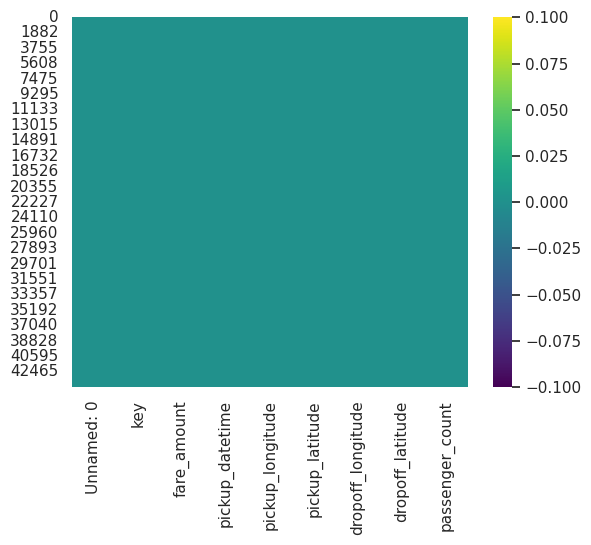

In [438]:
#any null value will be visible (distinct)
sns.heatmap(df.isnull(), cmap = 'viridis')

Visualisation des données à l'aide d'histogrammes

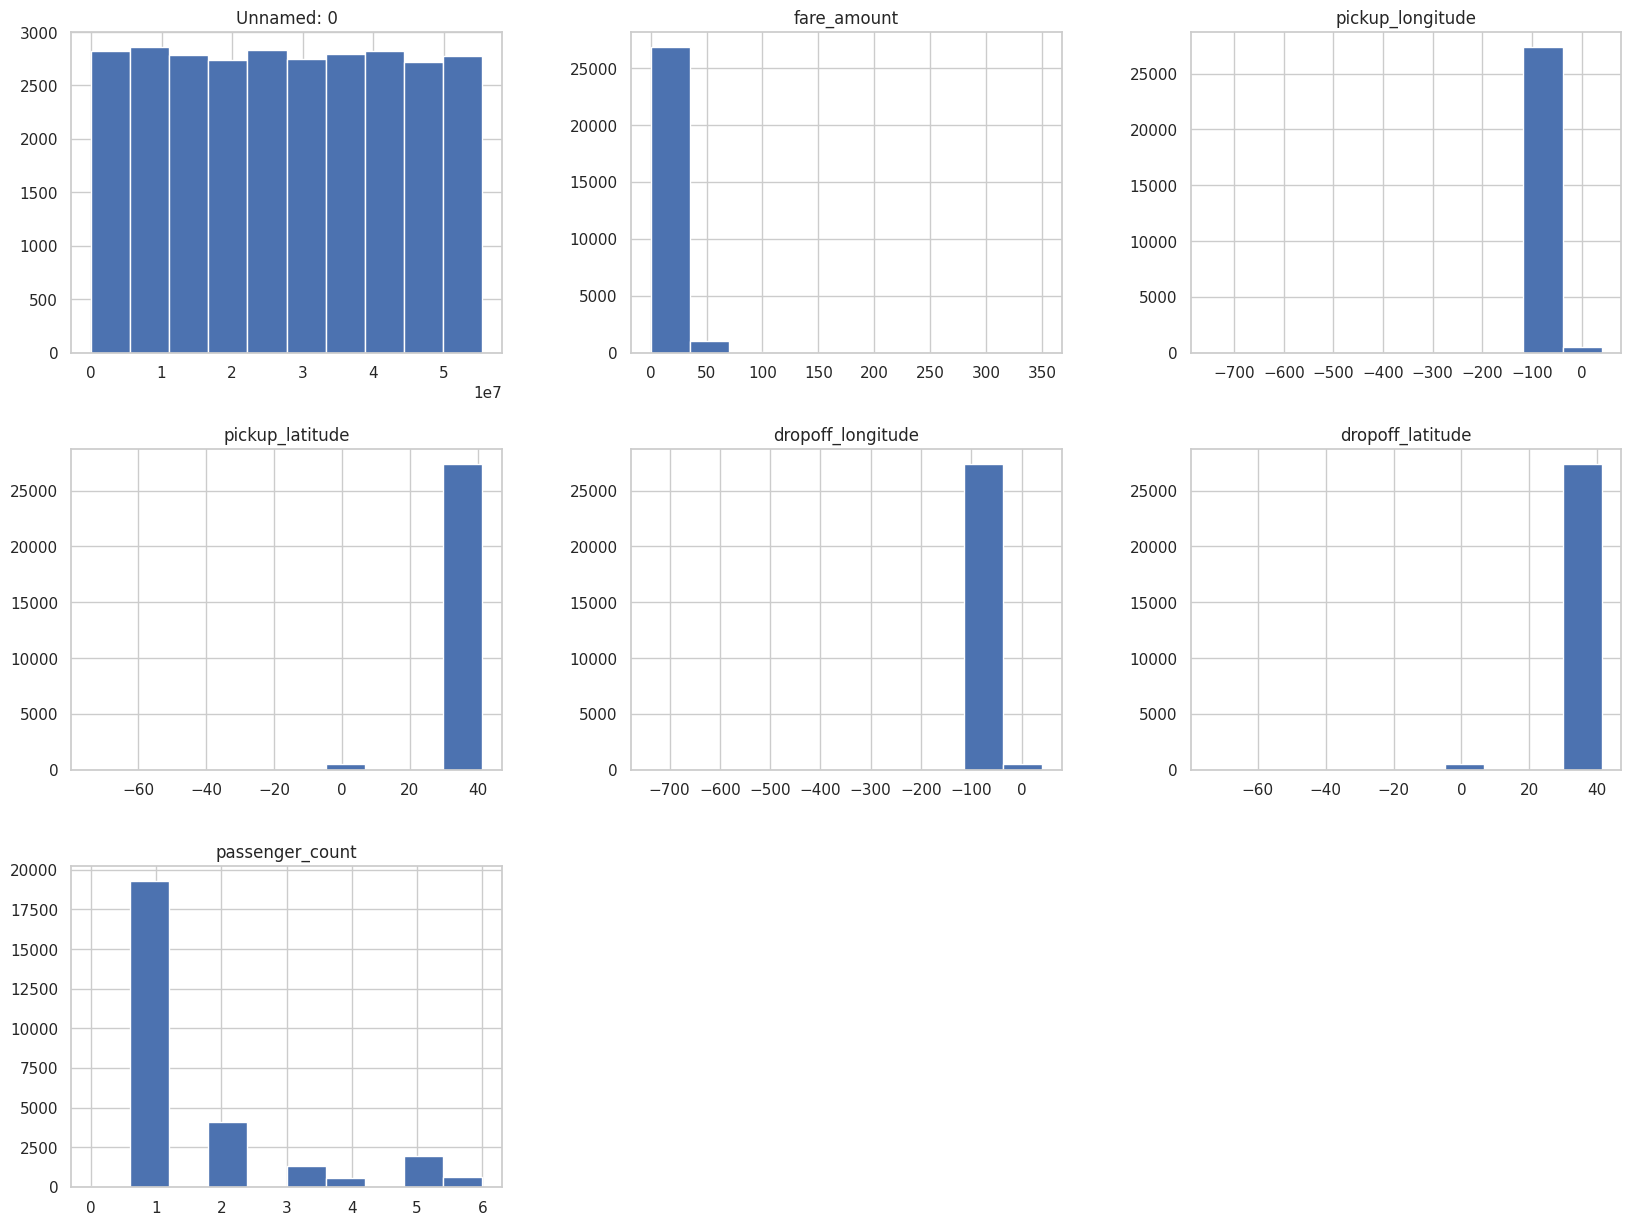

In [439]:
df.hist(figsize=(20,15))
plt.show()

### **Partie 2: Transformation de données**

**Encodage de la variable defects**


In [440]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Charger le DataFrame
df = pd.read_csv('datauber.csv')

# Encodage des variables catégorielles
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

print("\nDataset après encodage des variables catégorielles :")
print(df.head())

# Encodage de la variable cible
target = 'defects'  # Remplacez par le nom exact de la variable cible
if target in df.columns:
    # Vérifiez les valeurs manquantes
    if df[target].isnull().sum() > 0:
        print(f"\nErreur : la cible '{target}' contient des valeurs manquantes.")
    else:
        target_encoder = LabelEncoder()
        df[target] = target_encoder.fit_transform(df[target])
        print("\nCible encodée :")
        print(df[[target]].head())
else:
    print(f"\nErreur : la cible '{target}' n'est pas dans le dataset.")


Dataset après encodage des variables catégorielles :
   Unnamed: 0    key  fare_amount  pickup_datetime  pickup_longitude  \
0  24238194.0  41165          7.5            40968        -73.999817   
1  27835199.0   3492          7.7             3467        -73.994355   
2  44984355.0   4140         12.9            41842        -74.005043   
3  25894730.0   3156          5.3             3128        -73.976124   
4  17610152.0  36954         16.0            36749               NaN   

   pickup_latitude  dropoff_longitude  dropoff_latitude  passenger_count  
0        40.738354         -73.999512         40.723217              1.0  
1        40.728225         -73.994710         40.750325              1.0  
2        40.740770                NaN         40.772647              1.0  
3              NaN         -73.965316         40.803349              3.0  
4        40.744085         -73.973082               NaN              5.0  

Erreur : la cible 'defects' n'est pas dans le dataset.


**Normalisation**

In [441]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler


# Normalisation des données avant la matrice de corrélation
scaler = StandardScaler()
df_normalized = df.copy()
df_normalized[df.select_dtypes(include=[np.number]).columns] = scaler.fit_transform(df[df.select_dtypes(include=[np.number]).columns])


Convert Data Types

In [442]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])


# Feature Engineering

In [443]:
import pandas as pd
import numpy as np

# Assuming df is already defined and contains 'pickup_datetime', 'pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude'

# Extracting relevant datetime features
df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['pickup_day'] = df['pickup_datetime'].dt.day
df['pickup_month'] = df['pickup_datetime'].dt.month
df['pickup_minute'] = df['pickup_datetime'].dt.minute

# Create is_weekend column
df['is_weekend'] = df['pickup_day'].apply(lambda x: 1 if x >= 6 else 0)

# Add day of the week (0 = Monday, 6 = Sunday)
df['pickup_day_of_week'] = df['pickup_datetime'].dt.dayofweek

# Function to calculate distance using the Haversine formula
def calculate_distance(row):
    lat1, lon1 = np.radians(row['pickup_latitude']), np.radians(row['pickup_longitude'])
    lat2, lon2 = np.radians(row['dropoff_latitude']), np.radians(row['dropoff_longitude'])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371  # Radius of Earth in kilometers
    return c * r

# Calculate distance
df['distance_km'] = df.apply(calculate_distance, axis=1)

# Replace season with one-hot encoded columns
df['season_winter'] = df['pickup_month'].apply(lambda x: 1 if x in [12, 1, 2] else 0)
df['season_spring'] = df['pickup_month'].apply(lambda x: 1 if x in [3, 4, 5] else 0)
df['season_summer'] = df['pickup_month'].apply(lambda x: 1 if x in [6, 7, 8] else 0)
df['season_autumn'] = df['pickup_month'].apply(lambda x: 1 if x in [9, 10, 11] else 0)

# Drop the original season column if no longer needed
# df.drop(columns=['season'], inplace=True)  # Uncomment if you want to remove the original season column

# Now your DataFrame is cleaned and ready for further analysis
print(df.head())  # Display the first few rows to confirm changes

   Unnamed: 0    key  fare_amount               pickup_datetime  \
0  24238194.0  41165          7.5 1970-01-01 00:00:00.000040968   
1  27835199.0   3492          7.7 1970-01-01 00:00:00.000003467   
2  44984355.0   4140         12.9 1970-01-01 00:00:00.000041842   
3  25894730.0   3156          5.3 1970-01-01 00:00:00.000003128   
4  17610152.0  36954         16.0 1970-01-01 00:00:00.000036749   

   pickup_longitude  pickup_latitude  dropoff_longitude  dropoff_latitude  \
0        -73.999817        40.738354         -73.999512         40.723217   
1        -73.994355        40.728225         -73.994710         40.750325   
2        -74.005043        40.740770                NaN         40.772647   
3        -73.976124              NaN         -73.965316         40.803349   
4               NaN        40.744085         -73.973082               NaN   

   passenger_count  pickup_hour  pickup_day  pickup_month  pickup_minute  \
0              1.0            0           1             1 

In [444]:
# Data Cleaning

# 1. Handle missing values
df.dropna(inplace=True)  # Drop rows with any missing values

# Alternatively, you can use forward fill (uncomment if preferred):
# df.fillna(method='ffill', inplace=True)  # Forward fill missing values

# 2. Remove duplicates
df.drop_duplicates(inplace=True)

# 3. Convert data types if necessary
df['pickup_hour'] = df['pickup_hour'].astype(int)  # Convert pickup_hour to integer
df['pickup_day'] = df['pickup_day'].astype(int)  # Convert pickup_day to integer
df['pickup_month'] = df['pickup_month'].astype(int)  # Convert pickup_month to integer
df['is_weekend'] = df['is_weekend'].astype(int)  # Ensure is_weekend is an integer

# Convert season columns to categorical type for efficiency
season_columns = ['season_winter', 'season_spring', 'season_summer', 'season_autumn']
for col in season_columns:
    df[col] = df[col].astype('category')  # Convert season columns to category

# 4. Reset index if needed
df.reset_index(drop=True, inplace=True)

# Now your DataFrame is cleaned and ready for further analysis
print(df.info())  # Display DataFrame info to confirm changes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30942 entries, 0 to 30941
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Unnamed: 0          30942 non-null  float64       
 1   key                 30942 non-null  int64         
 2   fare_amount         30942 non-null  float64       
 3   pickup_datetime     30942 non-null  datetime64[ns]
 4   pickup_longitude    30942 non-null  float64       
 5   pickup_latitude     30942 non-null  float64       
 6   dropoff_longitude   30942 non-null  float64       
 7   dropoff_latitude    30942 non-null  float64       
 8   passenger_count     30942 non-null  float64       
 9   pickup_hour         30942 non-null  int64         
 10  pickup_day          30942 non-null  int64         
 11  pickup_month        30942 non-null  int64         
 12  pickup_minute       30942 non-null  int32         
 13  is_weekend          30942 non-null  int64     

# Data Visualization


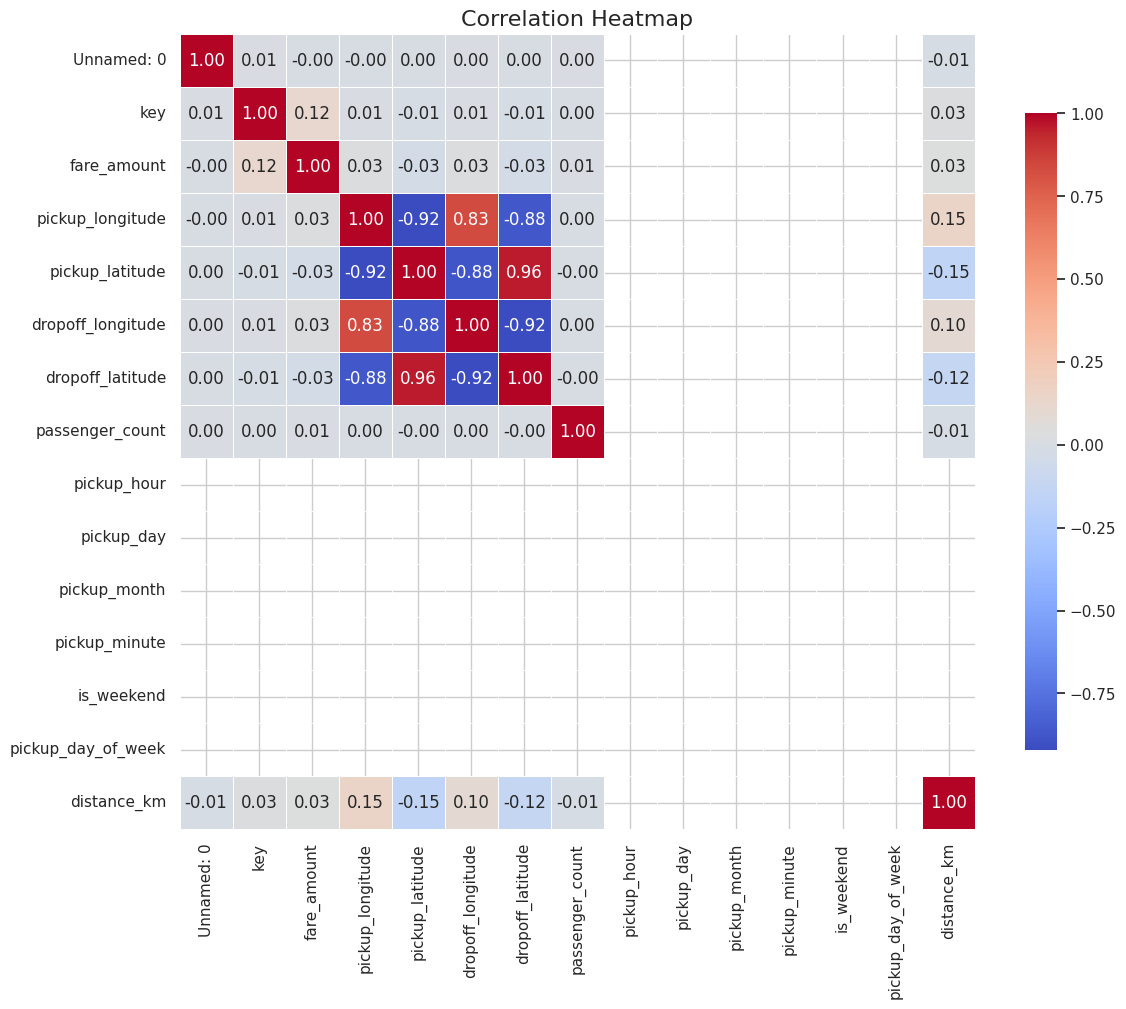

In [445]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df is your DataFrame

# 1. Drop non-numeric columns
numeric_df = df.select_dtypes(include=[np.number])  # Select only numeric columns

# 2. Handle missing values by dropping rows with NaNs in numeric columns
numeric_df.dropna(inplace=True)

# 3. Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# 4. Set the style of the visualization
sns.set(style='whitegrid')

# 5. Create a heatmap for the correlation matrix
plt.figure(figsize=(12, 10))
heatmap = sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True,
                       cbar_kws={"shrink": .8}, linewidths=.5)  # No masking to show all correlations
plt.title('Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

The 'season' column does not exist. Please use one-hot encoded columns instead.


/tmp/ipython-input-965967570.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted_df, x='season', y='fare_amount', palette='Set2')


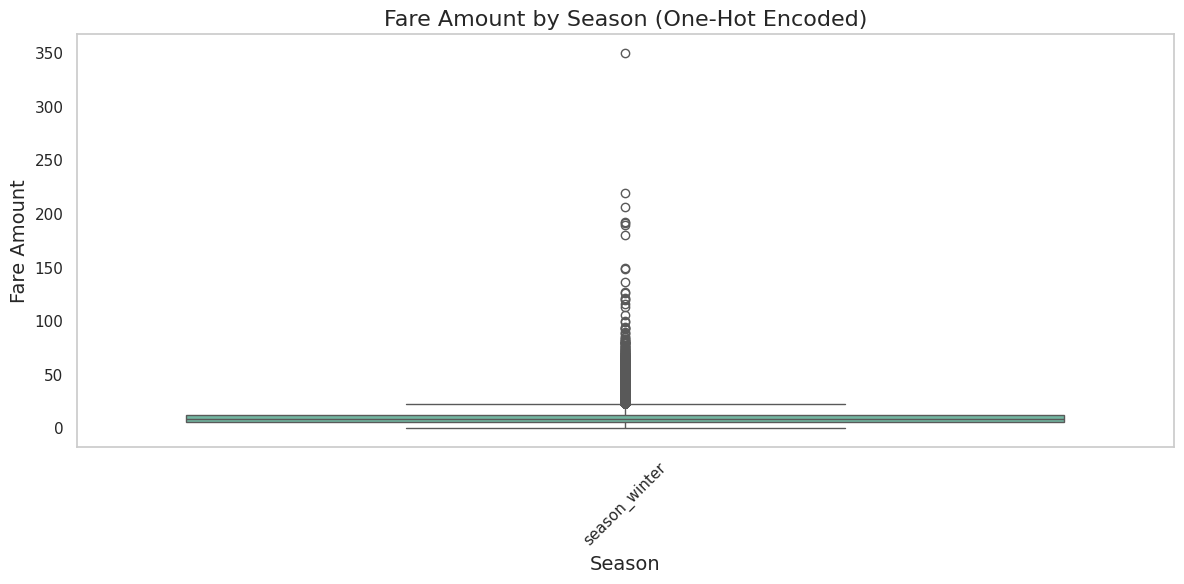

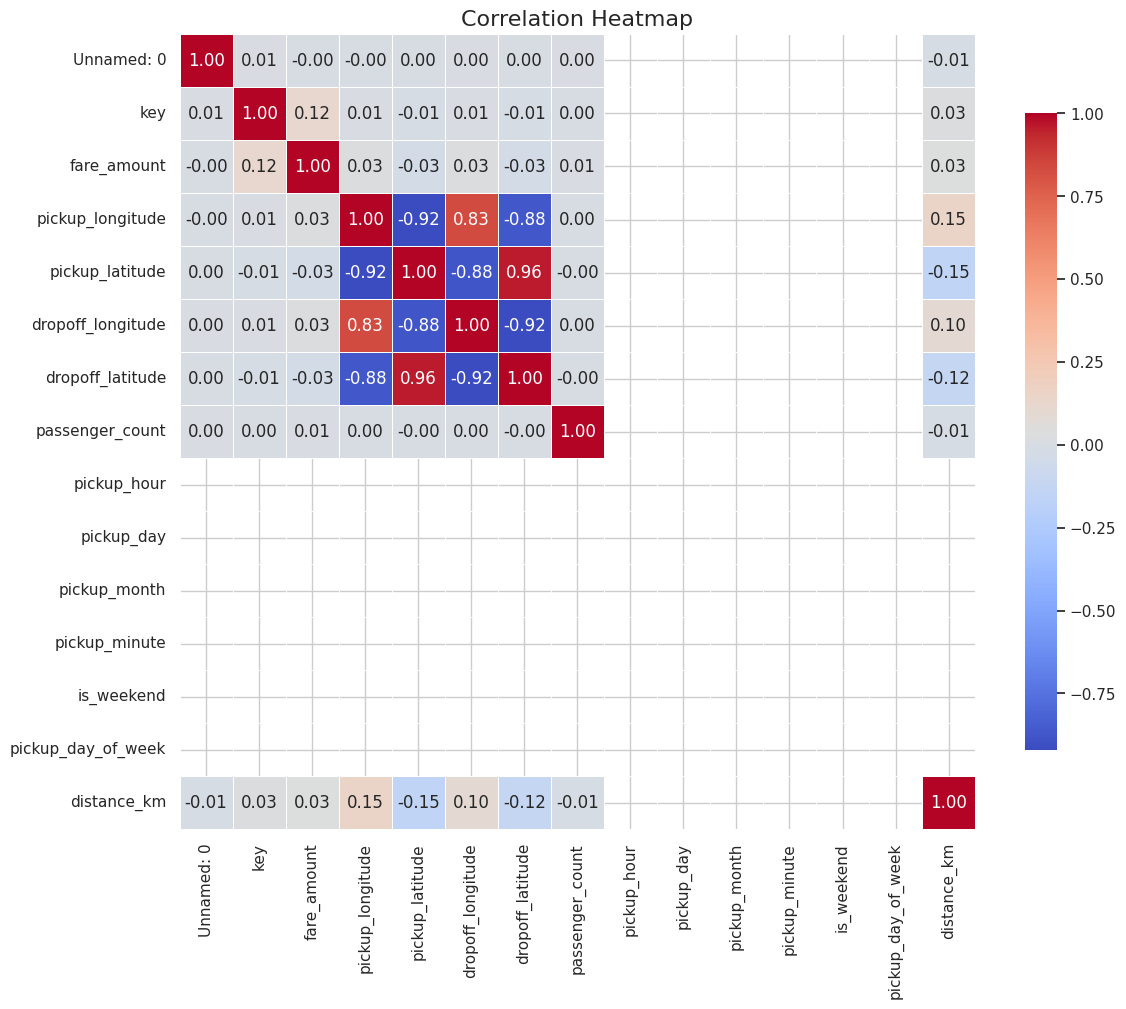

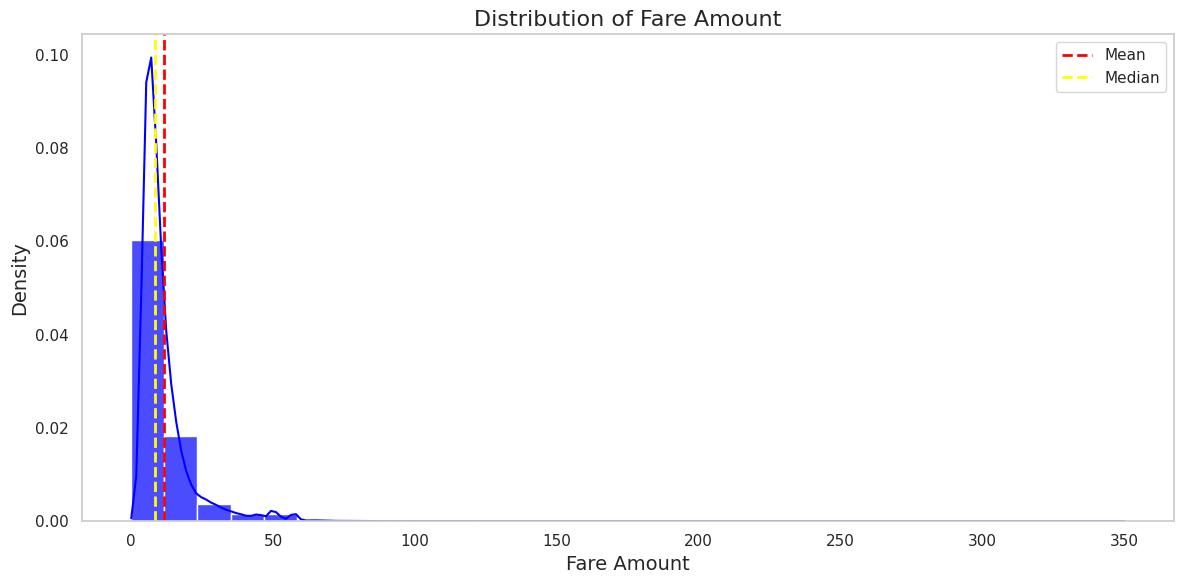

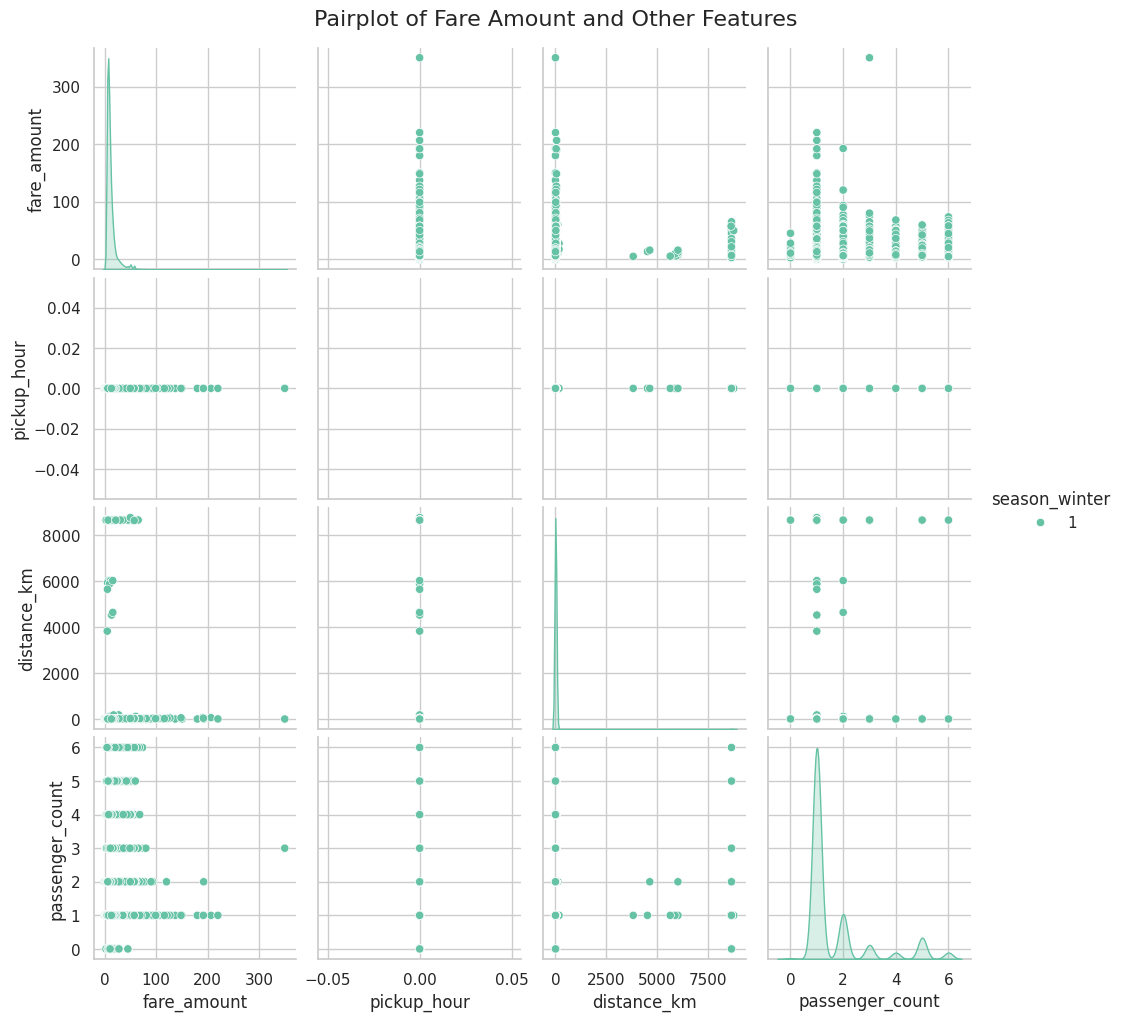

In [446]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is your DataFrame and has been preprocessed correctly

# Check if 'season' column exists
if 'season' in df.columns:
    # Boxplot for fare_amount by season
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x='season', y='fare_amount', palette='Set2')
    plt.title('Fare Amount by Season', fontsize=16)
    plt.xlabel('Season', fontsize=14)
    plt.ylabel('Fare Amount', fontsize=14)
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()
else:
    print("The 'season' column does not exist. Please use one-hot encoded columns instead.")

    # If using one-hot encoded columns, you can create a boxplot for each season
    melted_df = df.melt(id_vars=['fare_amount'],
                         value_vars=['season_winter', 'season_spring', 'season_summer', 'season_autumn'],
                         var_name='season', value_name='is_season')

    # Filter for seasons that are active (is_season == 1)
    melted_df = melted_df[melted_df['is_season'] == 1]

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=melted_df, x='season', y='fare_amount', palette='Set2')
    plt.title('Fare Amount by Season (One-Hot Encoded)', fontsize=16)
    plt.xlabel('Season', fontsize=14)
    plt.ylabel('Fare Amount', fontsize=14)
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 10))
numeric_df = df.select_dtypes(include=[np.number])  # Select only numeric columns
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True,
            cbar_kws={"shrink": .8}, linewidths=.5)
plt.title('Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

# Distribution of fare_amount with additional statistics
plt.figure(figsize=(12, 6))
sns.histplot(df['fare_amount'], bins=30, kde=True, color='blue', stat='density', alpha=0.7)
plt.axvline(df['fare_amount'].mean(), color='red', linestyle='dashed', linewidth=2, label='Mean')
plt.axvline(df['fare_amount'].median(), color='yellow', linestyle='dashed', linewidth=2, label='Median')
plt.title('Distribution of Fare Amount', fontsize=16)
plt.xlabel('Fare Amount', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Pairplot for additional insights
pairplot = sns.pairplot(df, vars=['fare_amount', 'pickup_hour', 'distance_km', 'passenger_count'],
             hue='season' if 'season' in df.columns else 'season_winter', palette='Set2', diag_kind='kde', markers='o', height=2.5)
pairplot.fig.suptitle('Pairplot of Fare Amount and Other Features', y=1.02, fontsize=16)
plt.show()

In [447]:
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_hour,pickup_day,pickup_month,pickup_minute,is_weekend,pickup_day_of_week,distance_km,season_winter,season_spring,season_summer,season_autumn
0,24238194.0,41165,7.5,1970-01-01 00:00:00.000040968,-73.999817,40.738354,-73.999512,40.723217,1.0,0,1,1,0,0,3,1.683323,1,0,0,0
1,27835199.0,3492,7.7,1970-01-01 00:00:00.000003467,-73.994355,40.728225,-73.994710,40.750325,1.0,0,1,1,0,0,3,2.457590,1,0,0,0
2,44470845.0,13430,4.9,1970-01-01 00:00:00.000013353,-73.969019,40.755910,-73.969019,40.755910,1.0,0,1,1,0,0,3,0.000000,1,0,0,0
3,44195482.0,26004,2.5,1970-01-01 00:00:00.000025892,0.000000,0.000000,0.000000,0.000000,1.0,0,1,1,0,0,3,0.000000,1,0,0,0
4,15822268.0,20389,9.7,1970-01-01 00:00:00.000020293,-73.975187,40.745767,-74.002720,40.743537,1.0,0,1,1,0,0,3,2.332711,1,0,0,0


# RandomForest !!

Features Importance in RandomForest Regression Model

/tmp/ipython-input-3433363059.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='viridis')


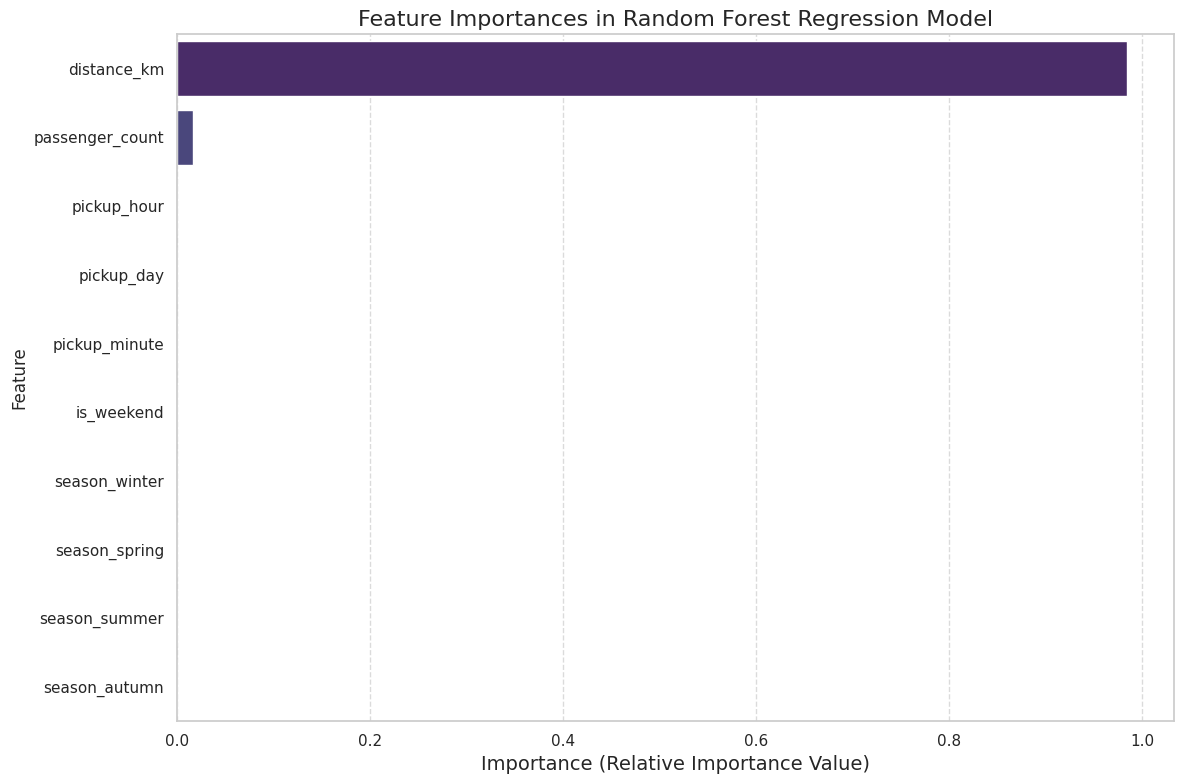

In [461]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# Check if the required columns exist in the DataFrame
required_columns = ['pickup_day', 'pickup_hour', 'pickup_minute', 'passenger_count', 'is_weekend',
                    'distance_km', 'season_winter', 'season_spring', 'season_summer', 'season_autumn']

missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    print(f"Missing columns in DataFrame: {missing_columns}")
else:
    # Define your features and target
    X = df[required_columns]
    y = df['fare_amount']  # Use 'fare_amount' as the target variable

    # Check for NaN values in the features
    if X.isnull().any().any():
        print("Warning: There are NaN values in the feature columns.")
        print(X.isnull().sum())

    # Create a ColumnTransformer for preprocessing
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', SimpleImputer(strategy='mean'),
             ['pickup_day', 'pickup_hour', 'pickup_minute', 'passenger_count', 'is_weekend', 'distance_km', 'season_winter', 'season_spring', 'season_summer', 'season_autumn']),
            # No need for OneHotEncoder since we are using pre-encoded features
        ])

    # Create the pipeline with preprocessing and the Random Forest model
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(random_state=42))  # Use RandomForestRegressor for predicting continuous outcomes
    ])

    # Fit the pipeline to the data
    pipeline.fit(X, y)

    # Get feature importances
    feature_importances = pipeline.named_steps['model'].feature_importances_

    # Combine with feature names
    feature_names = required_columns

    # Create a DataFrame for easier plotting
    if len(feature_names) == len(feature_importances):
        feature_importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': feature_importances
        })

        # Sort the DataFrame by absolute importance
        feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

        # Enhanced Plotting with Seaborn
        plt.figure(figsize=(12, 8))
        sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='viridis')
        plt.xlabel('Importance (Relative Importance Value)', fontsize=14)
        plt.title('Feature Importances in Random Forest Regression Model', fontsize=16)
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    else:
        print("Error: The number of features does not match the number of importance values.")

**Random Forest Predictions vs Actual Fare Amounts**

Mean Squared Error (MSE): 47.69
R² Score: 0.58


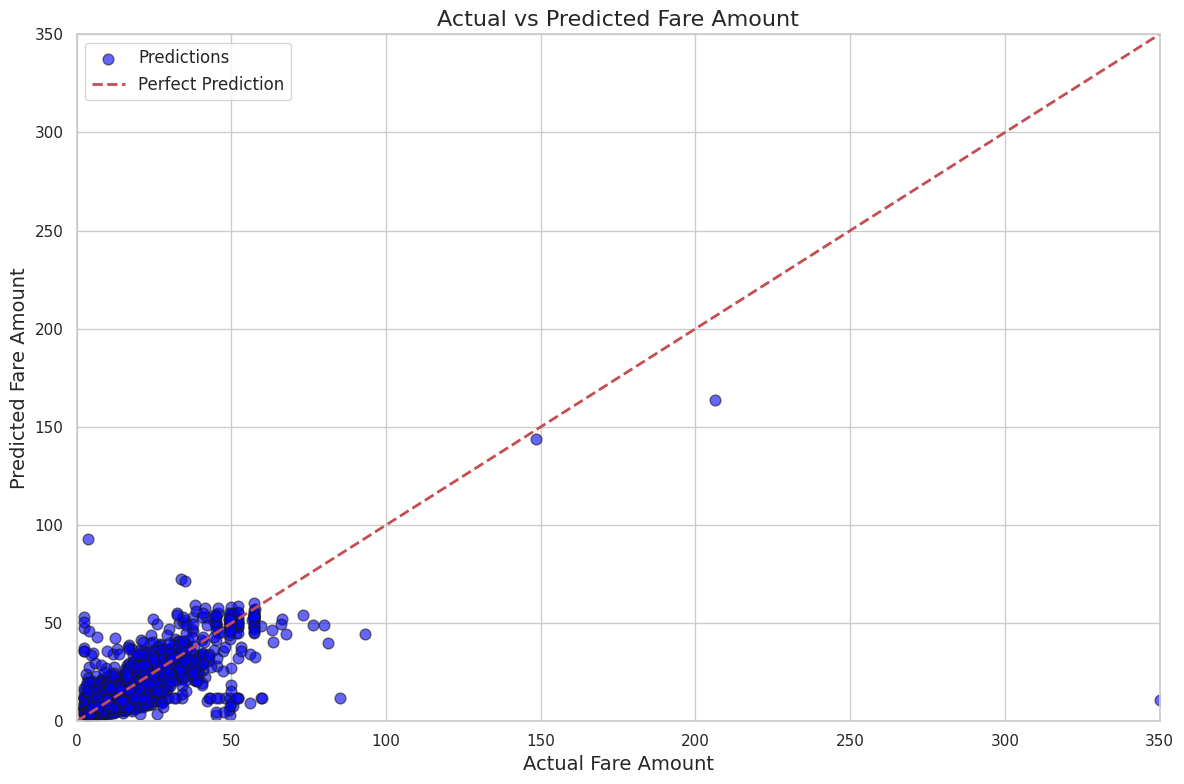

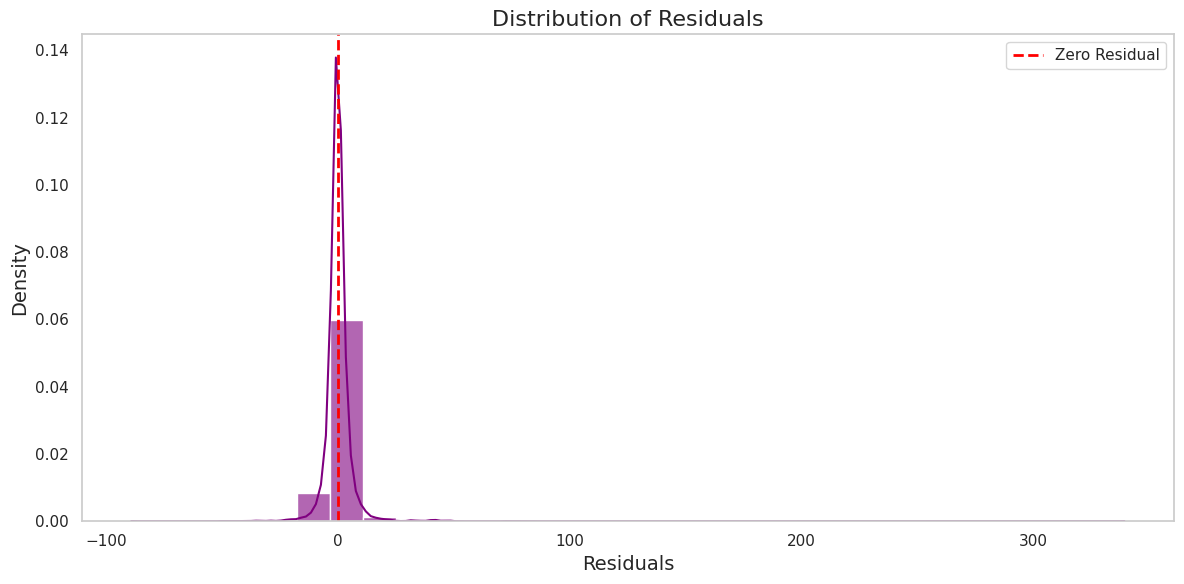

In [448]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import seaborn as sns

# Assuming df is your DataFrame and has been preprocessed correctly
# Ensure the necessary columns are present, including one-hot encoded season columns

# Define features and target, including one-hot encoded season columns
X = df[['pickup_day', 'pickup_hour', 'passenger_count', 'is_weekend', 'distance_km',
         'season_winter', 'season_spring', 'season_summer', 'season_autumn']]  # Include one-hot encoded columns
y = df['fare_amount']  # Dependent variable

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a pipeline with preprocessing and model
pipeline = Pipeline(steps=[
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Train the model
pipeline.fit(X_train, y_train)

# Predictions
y_pred = pipeline.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.2f}")

# Improved Visualization: Actual vs Predicted Fare Amounts
plt.figure(figsize=(12, 8))
plt.scatter(y_test, y_pred, color="blue", alpha=0.6, edgecolor='k', s=60, label="Predictions")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2, label="Perfect Prediction")  # Line for perfect predictions
plt.xlim([y.min(), y.max()])  # Set x-axis limits
plt.ylim([y.min(), y.max()])  # Set y-axis limits
plt.xlabel("Actual Fare Amount", fontsize=14)
plt.ylabel("Predicted Fare Amount", fontsize=14)
plt.title("Actual vs Predicted Fare Amount", fontsize=16)
plt.grid(True)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# Additional Residuals Plot
plt.figure(figsize=(12, 6))
residuals = y_test - y_pred
sns.histplot(residuals, bins=30, kde=True, color='purple', stat='density', alpha=0.6)
plt.axvline(0, color='red', linestyle='dashed', linewidth=2, label='Zero Residual')
plt.title('Distribution of Residuals', fontsize=16)
plt.xlabel('Residuals', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [449]:
# Calculate the average distance_km
average_distance = df['distance_km'].mean()

print(f"The average distance (km) is: {average_distance:.2f}")

The average distance (km) is: 20.00


In [450]:
import pandas as pd

def calculate_average_fare(file_path):
    """
    Reads the fare_amount column from the specified CSV file and calculates its average.

    Parameters:
    - file_path: str, path to the CSV file containing the dataset.

    Returns:
    - average_fare: float, the average fare_amount.
    """
    # Load the data
    df = pd.read_csv(file_path)

    # Check if 'fare_amount' column exists
    if 'fare_amount' not in df.columns:
        raise ValueError("The column 'fare_amount' does not exist in the dataset.")

    # Calculate the average fare_amount
    average_fare = df['fare_amount'].mean()

    return average_fare

# Example usage
file_path = 'datauber.csv'
average_fare = calculate_average_fare(file_path)
print("Average Fare Amount:", average_fare)

Average Fare Amount: 11.409232536655848


Regression Logistique

In [451]:
# Print the columns of the DataFrame
print(df.columns)

Index(['Unnamed: 0', 'key', 'fare_amount', 'pickup_datetime',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'passenger_count', 'pickup_hour', 'pickup_day',
       'pickup_month', 'pickup_minute', 'is_weekend', 'pickup_day_of_week',
       'distance_km', 'season_winter', 'season_spring', 'season_summer',
       'season_autumn'],
      dtype='object')


# Linear Regression

Feature Importance in Linear Regression Model

Number of features: 10
Number of coefficients: 10


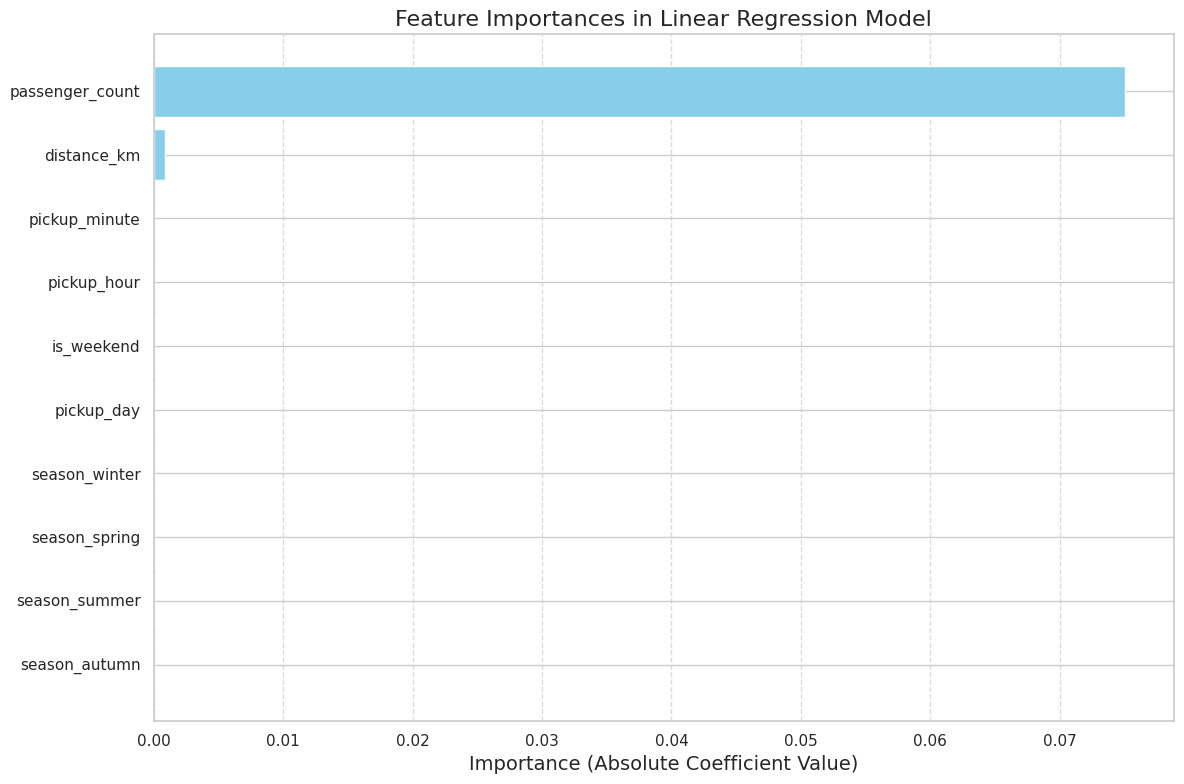

In [452]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Check if the required columns exist in the DataFrame
required_columns = ['pickup_day', 'pickup_hour', 'pickup_minute', 'passenger_count', 'is_weekend',
                    'distance_km', 'season_winter', 'season_spring', 'season_summer', 'season_autumn']

missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    print(f"Missing columns in DataFrame: {missing_columns}")
else:
    # Define your features and target
    X = df[required_columns]
    y = df['fare_amount']  # Use 'fare_amount' as the target variable

    # Check for NaN values in the features
    if X.isnull().any().any():
        print("Warning: There are NaN values in the feature columns.")
        print(X.isnull().sum())

    # Create a ColumnTransformer for preprocessing
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', SimpleImputer(strategy='mean'),
             ['pickup_day', 'pickup_hour', 'pickup_minute', 'passenger_count', 'is_weekend', 'distance_km', 'season_winter', 'season_spring', 'season_summer', 'season_autumn']),
            # No need for OneHotEncoder since we are using pre-encoded features
        ])

    # Create the pipeline with preprocessing and the Linear Regression model
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())  # Use LinearRegression for predicting continuous outcomes
    ])

    # Fit the pipeline to the data
    pipeline.fit(X, y)

    # Now you can access the coefficients
    coefficients = pipeline.named_steps['model'].coef_  # Get coefficients for regression

    # Combine with numeric feature names
    feature_names = required_columns

    # Debugging: Check lengths before creating DataFrame
    print(f"Number of features: {len(feature_names)}")
    print(f"Number of coefficients: {len(coefficients)}")

    # Create a DataFrame for easier plotting
    if len(feature_names) == len(coefficients):
        feature_importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': coefficients
        })

        # Sort the DataFrame by absolute importance
        feature_importance_df['Absolute Importance'] = abs(feature_importance_df['Importance'])
        feature_importance_df = feature_importance_df.sort_values(by='Absolute Importance', ascending=False)

        # Plotting
        plt.figure(figsize=(12, 8))
        plt.barh(feature_importance_df['Feature'], feature_importance_df['Absolute Importance'], color='skyblue')
        plt.xlabel('Importance (Absolute Coefficient Value)', fontsize=14)
        plt.title('Feature Importances in Linear Regression Model', fontsize=16)
        plt.gca().invert_yaxis()  # Invert y-axis for better visual
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    else:
        print("Error: The number of features does not match the number of coefficients.")

/tmp/ipython-input-11979810.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df, x='Absolute Importance', y='Feature', palette='viridis')


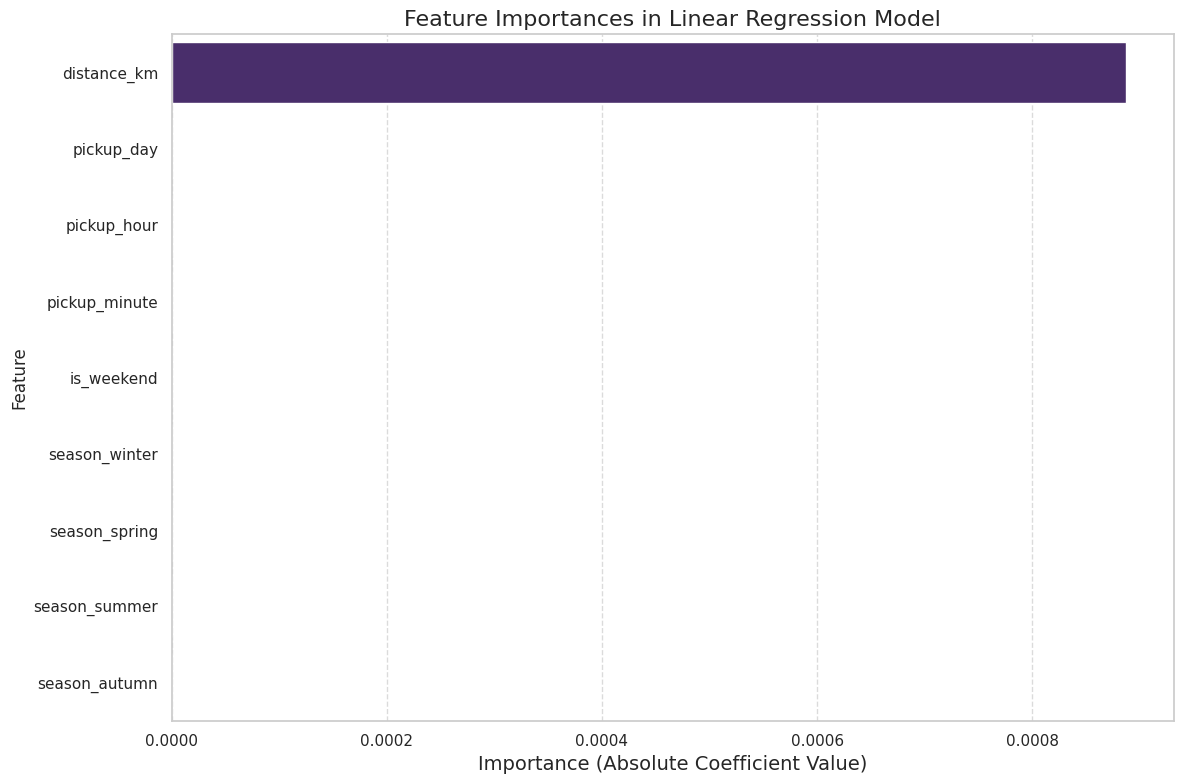

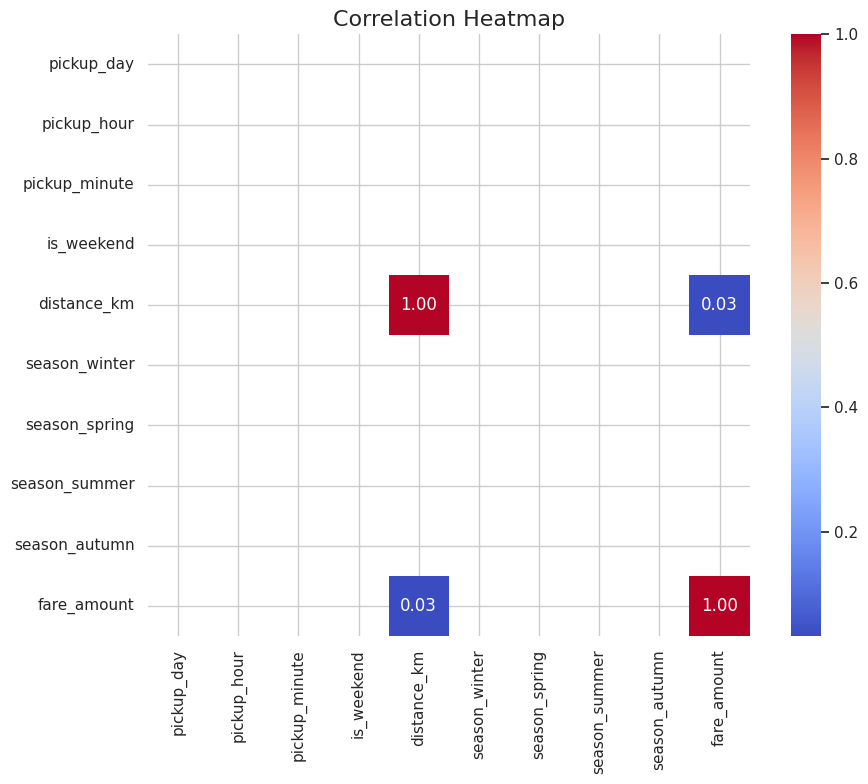

In [462]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

# Check if the required columns exist in the DataFrame
required_columns = ['pickup_day', 'pickup_hour', 'pickup_minute', 'passenger_count', 'is_weekend',
                    'distance_km', 'season_winter', 'season_spring', 'season_summer', 'season_autumn']

missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    print(f"Missing columns in DataFrame: {missing_columns}")
else:
    # Define your features and target
    X = df[required_columns]
    y = df['fare_amount']  # Use 'fare_amount' as the target variable

    # Check for NaN values in the features
    if X.isnull().any().any():
        print("Warning: There are NaN values in the feature columns.")
        print(X.isnull().sum())

    # Create a ColumnTransformer for preprocessing
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', SimpleImputer(strategy='mean'),
             ['pickup_day', 'pickup_hour', 'pickup_minute', 'passenger_count', 'is_weekend', 'distance_km','season_winter', 'season_spring', 'season_summer', 'season_autumn']),
            # No need for OneHotEncoder since we are using pre-encoded features
        ])

    # Create the pipeline with preprocessing and the Linear Regression model
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())  # Use LinearRegression for predicting continuous outcomes
    ])

    # Fit the pipeline to the data
    pipeline.fit(X, y)

    # Get the coefficients
    coefficients = pipeline.named_steps['model'].coef_

    # Combine with numeric feature names
    feature_names = required_columns

    # Create a DataFrame for easier plotting
    if len(feature_names) == len(coefficients):
        feature_importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': coefficients
        })

        # Sort the DataFrame by absolute importance
        feature_importance_df['Absolute Importance'] = abs(feature_importance_df['Importance'])
        feature_importance_df = feature_importance_df.sort_values(by='Absolute Importance', ascending=False)

        # Enhanced Plotting
        plt.figure(figsize=(12, 8))
        sns.barplot(data=feature_importance_df, x='Absolute Importance', y='Feature', palette='viridis')
        plt.xlabel('Importance (Absolute Coefficient Value)', fontsize=14)
        plt.title('Feature Importances in Linear Regression Model', fontsize=16)
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

        # Correlation Heatmap
        plt.figure(figsize=(10, 8))
        correlation_matrix = df[required_columns + ['fare_amount']].corr()
        sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
        plt.title('Correlation Heatmap', fontsize=16)
        plt.tight_layout()
        plt.show()
    else:
        print("Error: The number of features does not match the number of coefficients.")

Model

Constant Features: ['pickup_day', 'pickup_hour', 'pickup_minute', 'is_weekend', 'season_winter', 'season_spring', 'season_summer', 'season_autumn']
VIF Scores (before cleaning):
            Feature       VIF
0  passenger_count  1.001495
1      distance_km  1.001495
Mean Squared Error (MSE): 113.16342058944225
R² Score: 0.0009720485081531338
Feature Importance:
            Feature  Coefficient
0  passenger_count     0.108254
1      distance_km     0.000798


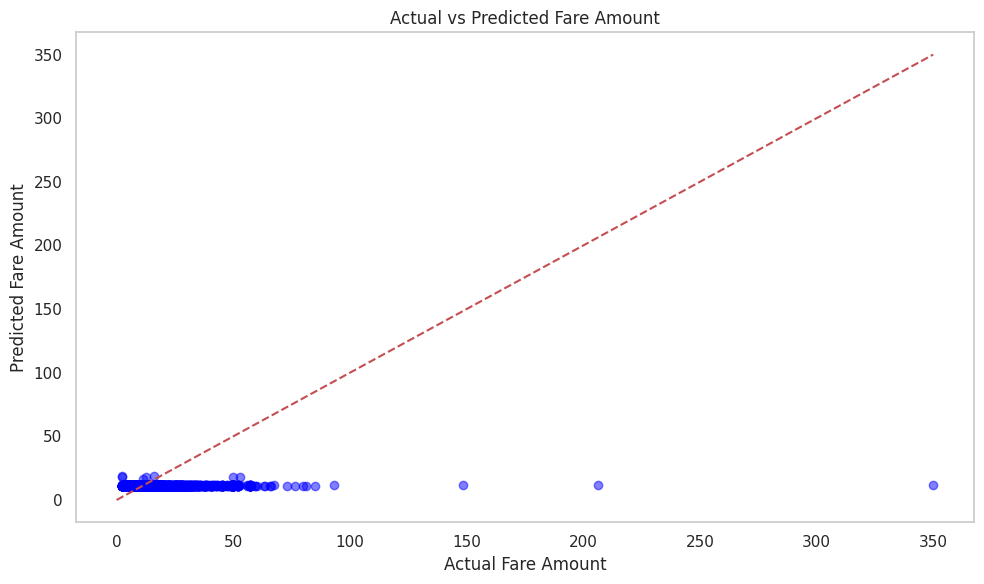

VIF Scores (after cleaning):
            Feature       VIF
0  passenger_count  1.001495
1      distance_km  1.001495


In [467]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Ensure there are no missing values
df.dropna(inplace=True)

# Define features and target
X = df[['pickup_day', 'pickup_hour', 'pickup_minute', 'passenger_count', 'is_weekend',
         'distance_km', 'season_winter', 'season_spring', 'season_summer', 'season_autumn']]
y = df['fare_amount']  # Dependent variable

# Check for constant features
constant_features = X.columns[X.nunique() <= 1]
print("Constant Features:", constant_features.tolist())
X = X.drop(columns=constant_features)

# Check for multicollinearity using VIF
X_vif = X.copy()
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print("VIF Scores (before cleaning):\n", vif_data)

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a ColumnTransformer
column_transformer = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', X.columns)  # Keep all numeric and one-hot encoded columns
    ])

# Create a pipeline with preprocessing and model (using Ridge for regularization)
pipeline = Pipeline(steps=[
    ('preprocessor', column_transformer),
    ('model', Ridge(alpha=1.0))  # Use Ridge Regression for better feature handling
])

# Train the model
pipeline.fit(X_train, y_train)

# Predictions
y_pred = pipeline.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

# Feature Importance
coefficients = pipeline.named_steps['model'].coef_
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': coefficients})
print("Feature Importance:\n", feature_importance_df)

# Visualization of Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color="blue", alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # Line for perfect predictions
plt.xlabel("Actual Fare Amount")
plt.ylabel("Predicted Fare Amount")
plt.title("Actual vs Predicted Fare Amount")
plt.grid()
plt.tight_layout()  # Adjust layout for better spacing
plt.show()

# Recheck VIF after dropping constant features
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("VIF Scores (after cleaning):\n", vif_data)

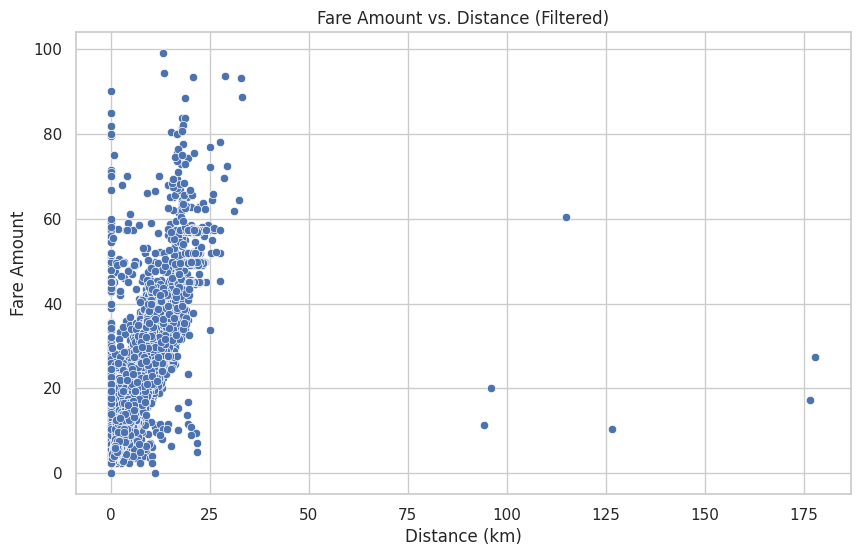

In [454]:
# Remove outliers based on distance and fare
filtered_df = df[(df['distance_km'] < 1000) & (df['fare_amount'] < 100)]

plt.figure(figsize=(10, 6))
sns.scatterplot(x='distance_km', y='fare_amount', data=filtered_df)
plt.title('Fare Amount vs. Distance (Filtered)')
plt.xlabel('Distance (km)')
plt.ylabel('Fare Amount')
plt.show()

In [455]:
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_hour,pickup_day,pickup_month,pickup_minute,is_weekend,pickup_day_of_week,distance_km,season_winter,season_spring,season_summer,season_autumn
0,24238194.0,41165,7.5,1970-01-01 00:00:00.000040968,-73.999817,40.738354,-73.999512,40.723217,1.0,0,1,1,0,0,3,1.683323,1,0,0,0
1,27835199.0,3492,7.7,1970-01-01 00:00:00.000003467,-73.994355,40.728225,-73.994710,40.750325,1.0,0,1,1,0,0,3,2.457590,1,0,0,0
2,44470845.0,13430,4.9,1970-01-01 00:00:00.000013353,-73.969019,40.755910,-73.969019,40.755910,1.0,0,1,1,0,0,3,0.000000,1,0,0,0
3,44195482.0,26004,2.5,1970-01-01 00:00:00.000025892,0.000000,0.000000,0.000000,0.000000,1.0,0,1,1,0,0,3,0.000000,1,0,0,0
4,15822268.0,20389,9.7,1970-01-01 00:00:00.000020293,-73.975187,40.745767,-74.002720,40.743537,1.0,0,1,1,0,0,3,2.332711,1,0,0,0


# **Gradient Boosting**

Features Importance for Gradient Boosting Model

           Feature  Importance
4      distance_km    0.998781
2  passenger_count    0.001219
0       pickup_day    0.000000
1      pickup_hour    0.000000
3       is_weekend    0.000000
5    season_winter    0.000000
6    season_spring    0.000000
7    season_summer    0.000000
8    season_autumn    0.000000


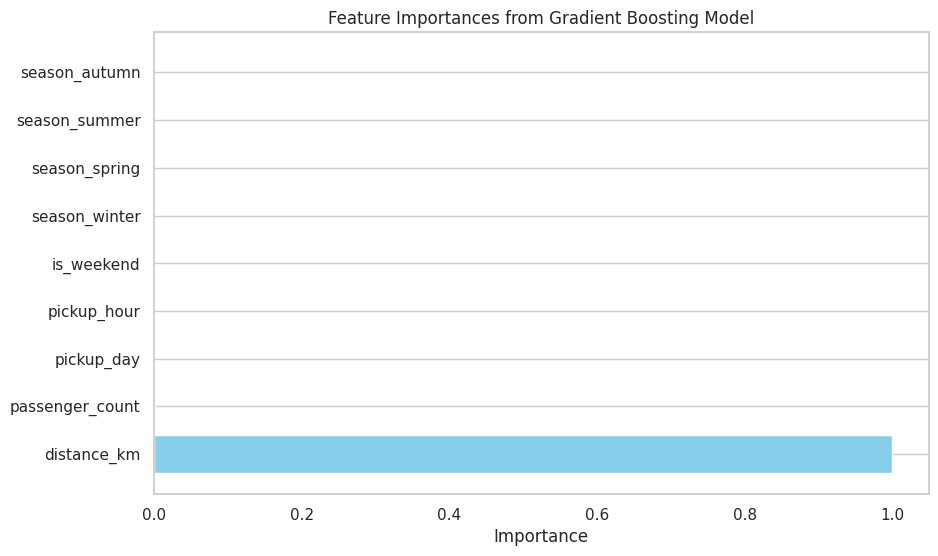

In [469]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Assuming df is your DataFrame and has been preprocessed correctly
# Ensure the necessary columns are included in your DataFrame

# Define features and target variable
X = df[['pickup_day', 'pickup_hour', 'passenger_count', 'is_weekend', 'distance_km',
         'season_winter', 'season_spring', 'season_summer', 'season_autumn']]
y = df['fare_amount']  # Dependent variable

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Gradient Boosting model
model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model.fit(X_train, y_train)

# Calculate feature importances
importances = model.feature_importances_

# Create a DataFrame to hold feature importances
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

# Sort the DataFrame by importance
feature_importance_df.sort_values(by='Importance', ascending=False, inplace=True)

# Print feature importances
print(feature_importance_df)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Feature Importances from Gradient Boosting Model')
plt.grid(axis='x')
plt.show()

**Gradient Boosting Model for Fare Prediction**

Mean Squared Error (MSE): 40.47
R² Score: 0.64


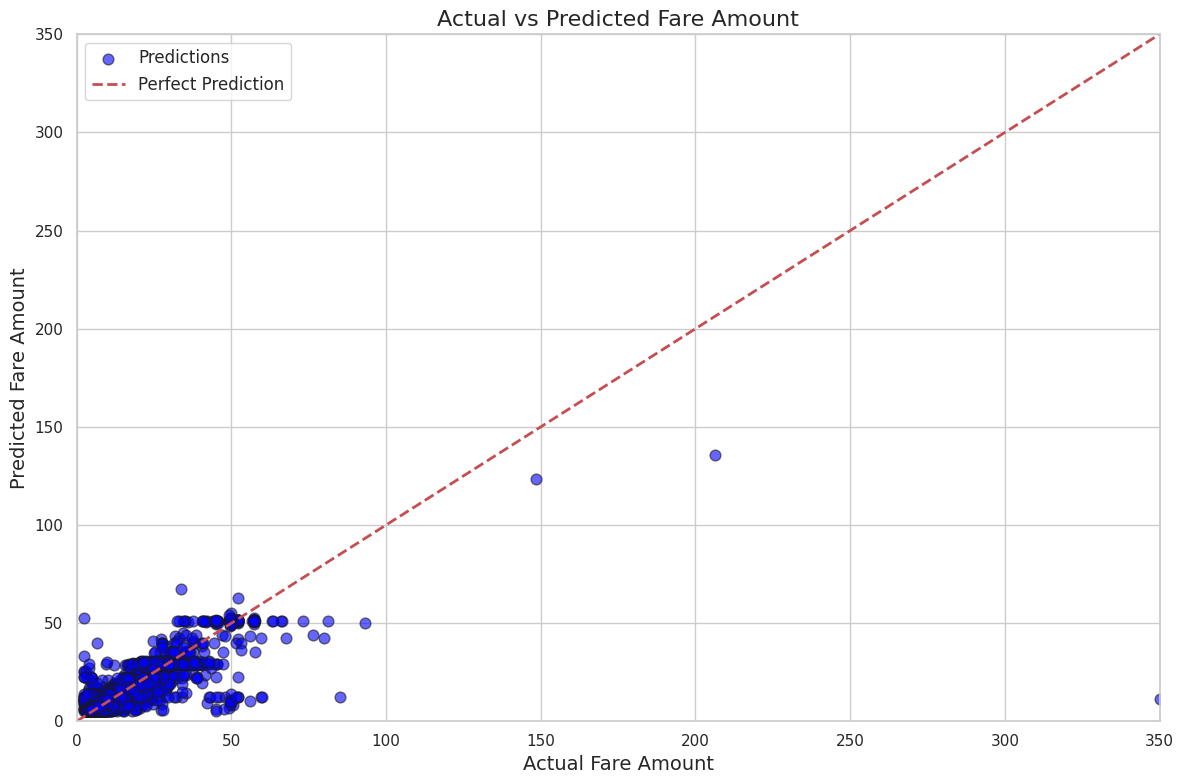

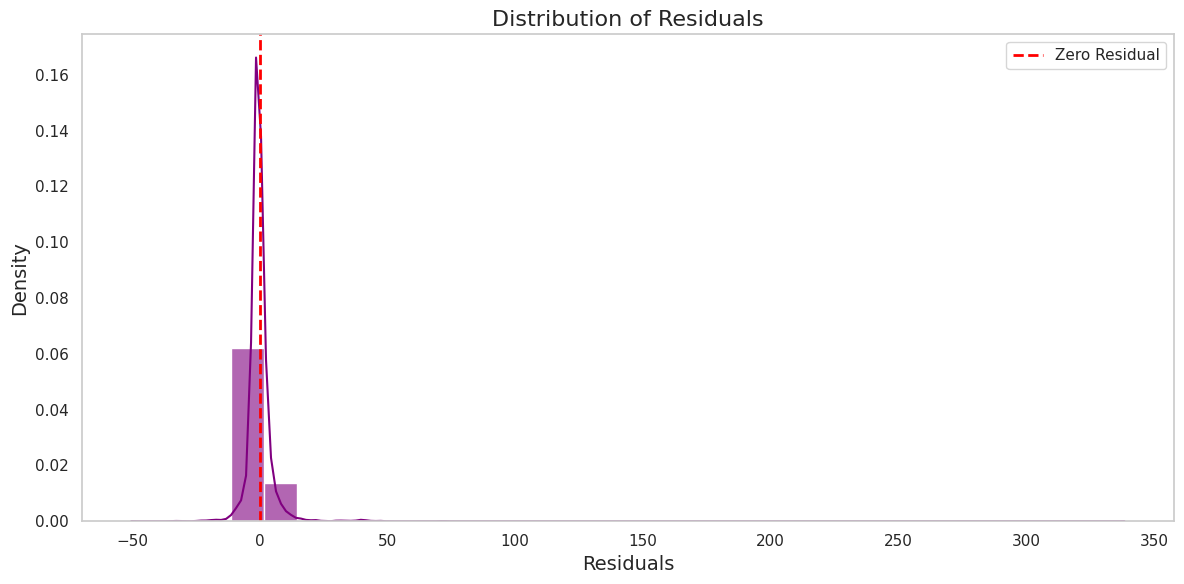

In [468]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline

# Assuming df is your DataFrame and has been preprocessed correctly
# Ensure the necessary columns are present, including one-hot encoded season columns

# Define features and target, including one-hot encoded season columns
X = df[['pickup_day', 'pickup_hour', 'passenger_count', 'is_weekend', 'distance_km',
         'season_winter', 'season_spring', 'season_summer', 'season_autumn']]  # Include one-hot encoded columns
y = df['fare_amount']  # Dependent variable

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a pipeline with preprocessing and model
pipeline = Pipeline(steps=[
    ('model', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42))
])

# Train the model
pipeline.fit(X_train, y_train)

# Predictions
y_pred = pipeline.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.2f}")

# Improved Visualization: Actual vs Predicted Fare Amounts
plt.figure(figsize=(12, 8))
plt.scatter(y_test, y_pred, color="blue", alpha=0.6, edgecolor='k', s=60, label="Predictions")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2, label="Perfect Prediction")  # Line for perfect predictions
plt.xlim([y.min(), y.max()])  # Set x-axis limits
plt.ylim([y.min(), y.max()])  # Set y-axis limits
plt.xlabel("Actual Fare Amount", fontsize=14)
plt.ylabel("Predicted Fare Amount", fontsize=14)
plt.title("Actual vs Predicted Fare Amount", fontsize=16)
plt.grid(True)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# Additional Residuals Plot
plt.figure(figsize=(12, 6))
residuals = y_test - y_pred
sns.histplot(residuals, bins=30, kde=True, color='purple', stat='density', alpha=0.6)
plt.axvline(0, color='red', linestyle='dashed', linewidth=2, label='Zero Residual')
plt.title('Distribution of Residuals', fontsize=16)
plt.xlabel('Residuals', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()